In [63]:
# Loading  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import levene, ttest_ind, mannwhitneyu, loguniform


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score, 
    recall_score,
    precision_score)




import mlflow
from mlflow.models import infer_signature




from pathlib import Path
import time
from datetime import datetime, timezone
import joblib
import json


In [3]:
file_path = Path("../data/Womens Clothing E-Commerce Reviews.csv")

df = pd.read_csv(file_path)
df_orignal = df.copy()
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')


Number of rows: 23486
Number of columns: 11


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 9.5 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


**Notes**:  
* Missing values in a `Title`, `Review Text`, `Division Name`, `Department Name`, `Class Name`, will need further inspection
* the max value in 	`Positive Feedback Count` might be an entry error, will need to be inspected
* No negative values in the data
* The mean values of `Rating` and `Positive Feedback Count` are larger than the median values indicating a right skew distribution.

In [7]:
def data_summary(df: pd.DataFrame) -> pd.DataFrame:
    missing_perc = round(df.isna().mean() * 100, 2)
    unique_values = df.nunique()
    col_types = df.dtypes
    duplicates = df.duplicated().sum()

    print(f'Number of duplicates entires : {duplicates}')
    summary_df = pd.DataFrame({
        'missing_perc' : missing_perc,
        'unique_values' : unique_values,
        'col_type' : col_types
    })
    return summary_df[summary_df['missing_perc'] > 0.0].sort_values(by='missing_perc', ascending=False)

data_summary(df=df)

Number of duplicates entires : 0


,missing_perc,unique_values,col_type
Title,16.22,13993,str
Review Text,3.60,22634,str
Division Name,0.06,3,str
Department Name,0.06,6,str
Class Name,0.06,20,str


**Notes**:  
* No duplicated entries
* `Title` column has the largest number of missing values
* `Positive Feedback Count` is right skewed. Most items get 0–7 upvotes, so anything with 8+ upvotes gets flagged as an extreme value.
* `Age` Only extreme ages outside 7 to 79 years old are flagged.

# EDA

## Univariate Data Analysis

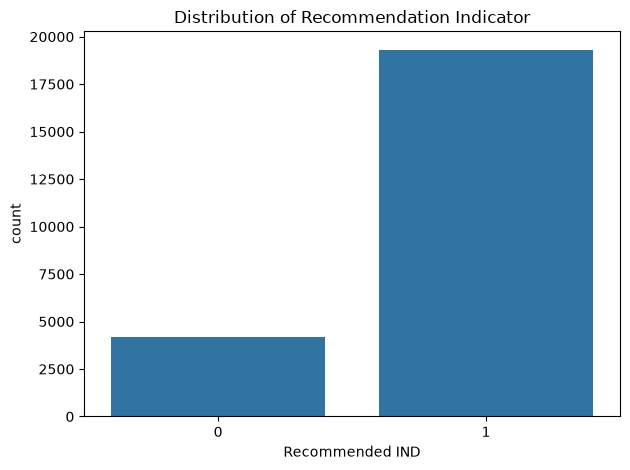

In [8]:
sns.countplot(data=df, x='Recommended IND')
plt.title('Distribution of Recommendation Indicator')
plt.tight_layout()
plt.show()

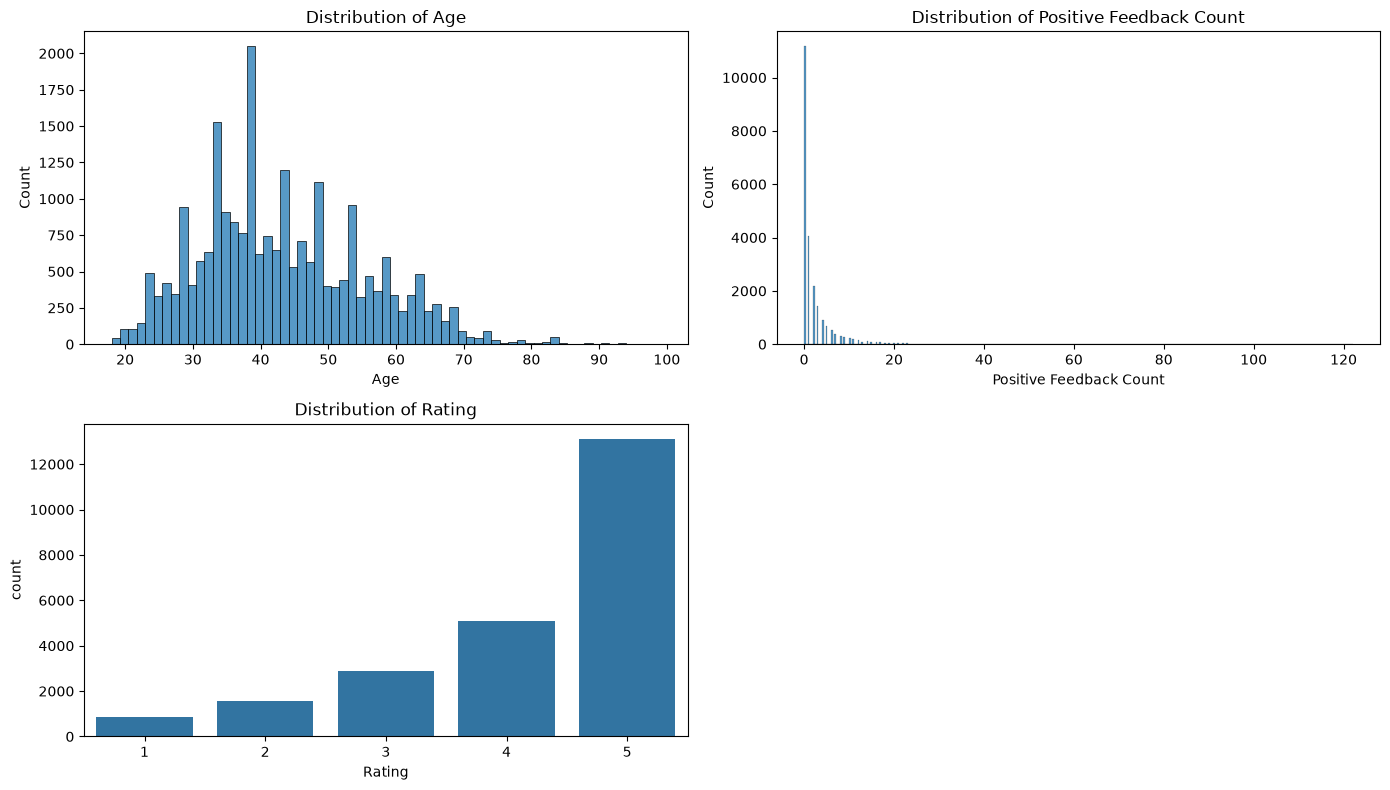

In [9]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14,8))
axs = axs.flatten()

sns.histplot(data=df, x='Age', ax=axs[0])
axs[0].set_title("Distribution of Age")

sns.histplot(data=df, x='Positive Feedback Count', ax=axs[1])
axs[1].set_title("Distribution of Positive Feedback Count")

sns.countplot(data=df, x='Rating',ax=axs[2])
axs[2].set_title("Distribution of Rating")

axs[3].set_visible(False)
plt.tight_layout()
plt.show()



**Notes**:  
* `Recommendation Indicator` Exhibits significant class imbalance
* `Age` displays a slight right skew, with the majority of shoppers concentrated in the 35–50 demographic. and `Positive Feedback Count` is highly skewed probably because of the 120 entry that might be a popular item or an entry error.
* `Rating` column shows that a rating of 5 is the dominant rating for the website followed by 4 and 3.

## Bivariate Analysis

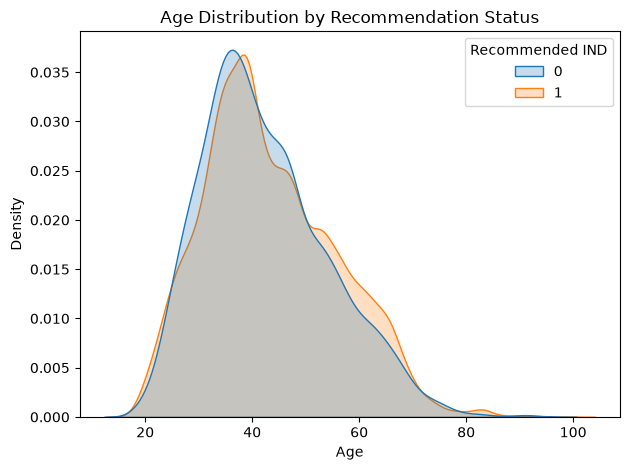

In [10]:
sns.kdeplot(data=df, x='Age', hue='Recommended IND', common_norm=False, fill=True)
plt.title("Age Distribution by Recommendation Status")
plt.tight_layout()
plt.show()

In [11]:
age_groups = [18, 29, 39, 49, 59, 100] 
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df['age_groups'] = pd.cut(df['Age'], bins=age_groups, labels=labels, right=True)

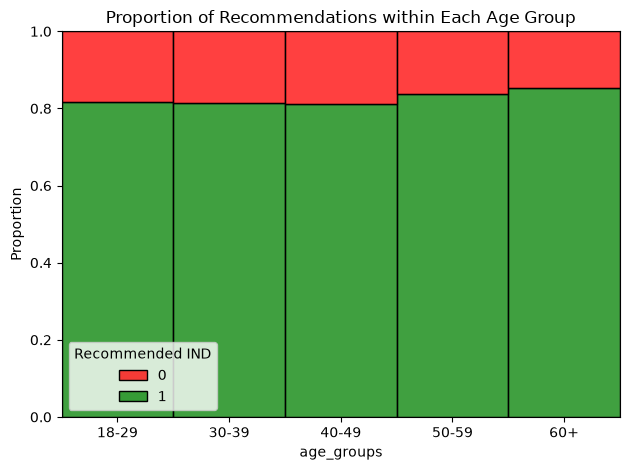

In [12]:
sns.histplot(
    data=df,
    x="age_groups",
    hue="Recommended IND",
    multiple="fill", 
    stat="proportion",
    palette={0: 'red', 1: 'green'})

plt.title("Proportion of Recommendations within Each Age Group")
plt.tight_layout()
plt.show()

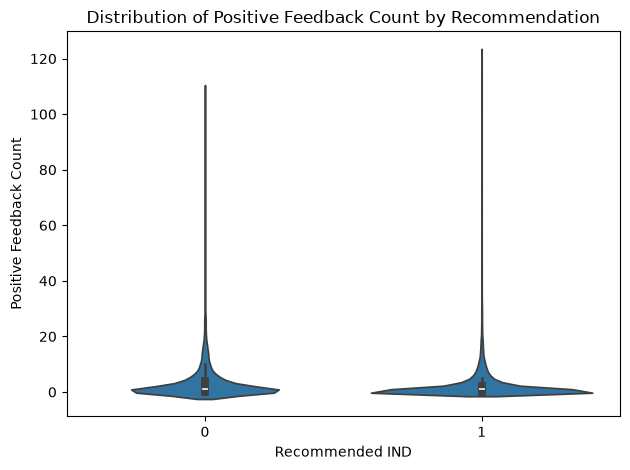

In [13]:
sns.violinplot(data=df, x='Recommended IND', y='Positive Feedback Count')
plt.title("Distribution of Positive Feedback Count by Recommendation")
plt.tight_layout()
plt.show()

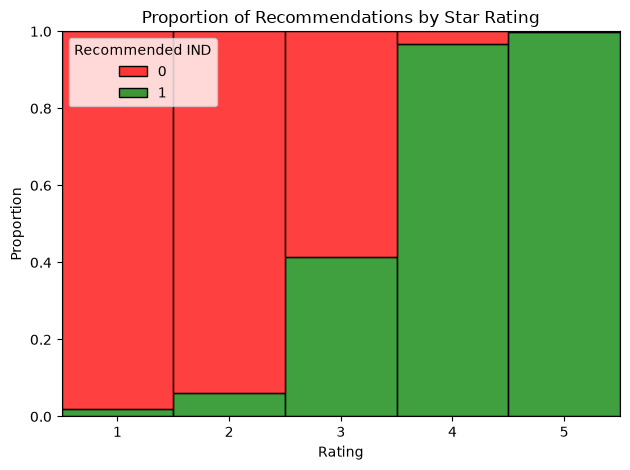

In [14]:
sns.histplot(data=df,  x='Rating',hue='Recommended IND', multiple='fill', stat='proportion', discrete=True, palette={0:'red', 1:'green'})
plt.title("Proportion of Recommendations by Star Rating")
plt.tight_layout()
plt.show()

## Mutlivariate analysis

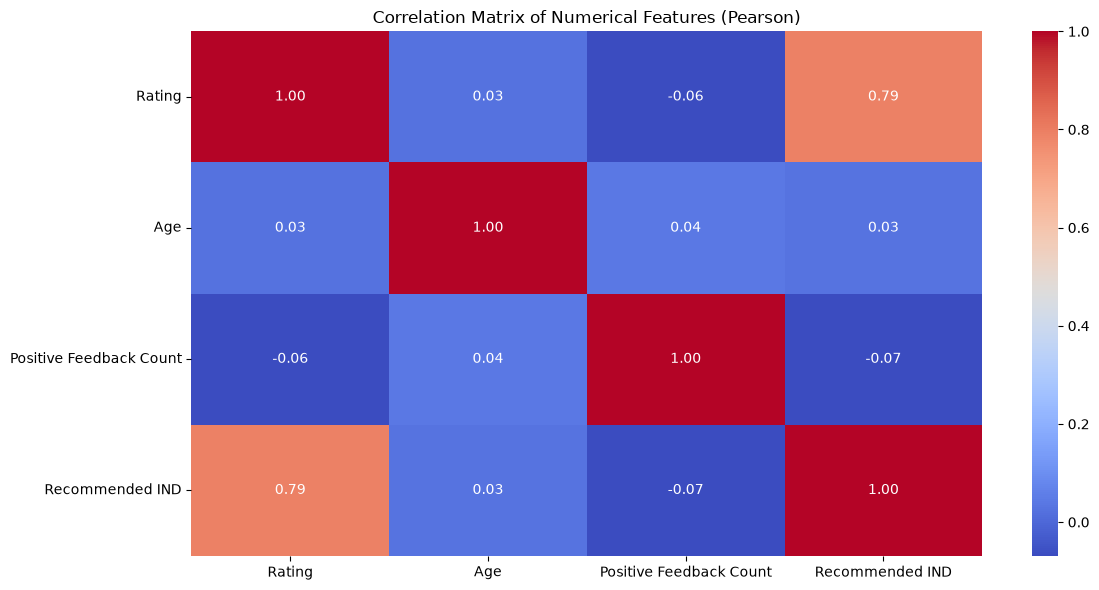

In [15]:
num_cols = df[['Rating', 'Age', 'Positive Feedback Count', 'Recommended IND']]
pearson_corr = num_cols.corr("pearson")

plt.figure(figsize=(12,6))
sns.heatmap(data=pearson_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numerical Features (Pearson)")
plt.tight_layout()
plt.show()

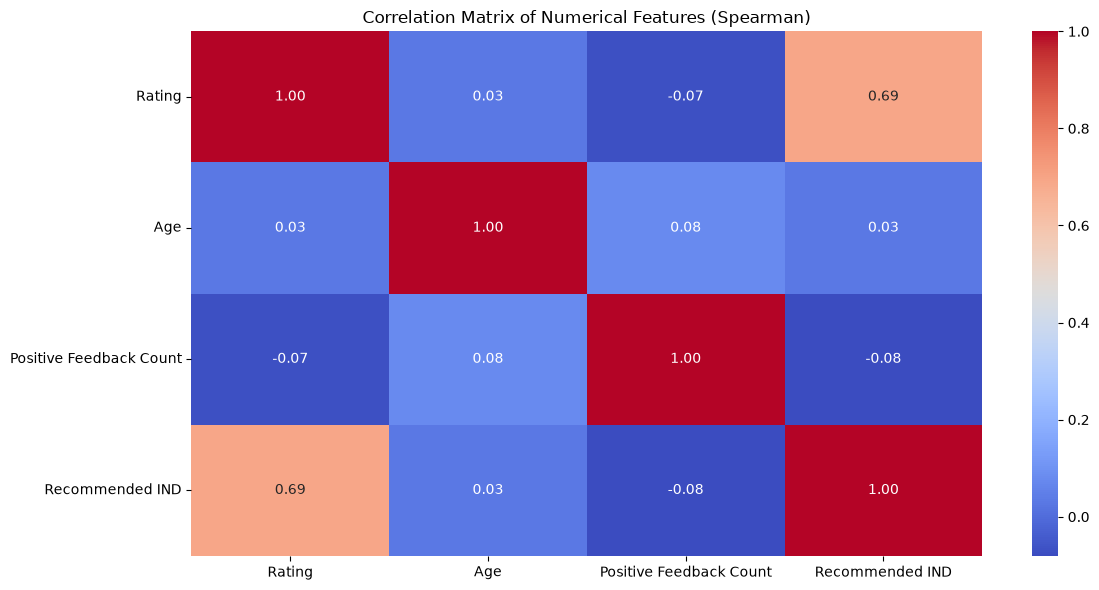

In [16]:
spearman_corr = num_cols.corr('spearman')

plt.figure(figsize=(12,6))
sns.heatmap(data=spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Numerical Features (Spearman)")
plt.tight_layout()
plt.show()

# Model building

In [17]:
df = df_orignal.copy()
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [18]:
df = df.dropna(subset=['Review Text'])

X = df.drop('Recommended IND', axis=1)
y = df['Recommended IND']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## Statistical Testing


In [19]:
def outliers(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df[['Positive Feedback Count', 'Age']]
    results = []
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = q3 - q1
        lower_bound, upper_bound = q1 - (IQR * 1.5), q3 + (IQR * 1.5)
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        perc_outliers = round(outliers / len(df) * 100, 2)
        results.append({
            'col' : col,
            'outliers' : outliers,
            'perc_outliers' : perc_outliers,
            'lower_bound' : lower_bound,
            'upper_bound' : upper_bound
        })
    return pd.DataFrame(results).sort_values(by='outliers', ascending=False)

outliers(df=X_train)

,col,outliers,perc_outliers,lower_bound,upper_bound
0,Positive Feedback Count,1692,9.34,-4.5,7.5
1,Age,83,0.46,7.0,79.0


In [20]:
group_recommended = X_train.loc[y_train == 1, 'Age']
group_not_recommended = X_train.loc[y_train == 0, 'Age']

stat, p = levene(group_recommended, group_not_recommended)
print(f"Levene p-value: {p}")
if p < 0.05:
    print("Variances differ significantly")
else:
    print("No significant evidence of different variances")

Levene p-value: 8.061302868075239e-07
Variances differ significantly


In [21]:
stat, p = ttest_ind(group_recommended, group_not_recommended, equal_var=False)
print(f'p-values is : {p}')
if p < 0.05:
    print("Reject Null hypothesis, mean age differs between groups")
else:
    print("Cannot reject Null hypothetis, mean age is equal between recommended and not-recommended groups")

p-values is : 1.8226557125756308e-07
Reject Null hypothesis, mean age differs between groups


In [22]:
group_recommended = X_train.loc[y_train == 1, 'Positive Feedback Count']
group_not_recommended = X_train.loc[y_train == 0, 'Positive Feedback Count']

stat, p = mannwhitneyu(group_recommended, group_not_recommended)
print(f'p-value: {p}')
if p < 0.05:
    print("Reject Null Hypothesis: There is a statistically significant difference in the distribution of Positive Feedback Count between recommended and non-recommended reviews.")
else:
    print("Fail to Reject Null Hypothesis: No statistically significant difference in Positive Feedback Count between recommended and non-recommended reviews.")

p-value: 1.280106394617727e-24
Reject Null Hypothesis: There is a statistically significant difference in the distribution of Positive Feedback Count between recommended and non-recommended reviews.


**Notes**:  
* An independent $t$-test indicates a statistically significant difference in mean Age between recommenders and non-recommenders.
* A Mann-Whitney U test confirms a statistically significant difference in the distribution of Positive Feedback Count between recommended and non-recommended reviews ($p < 0.05$).

## Data Preprocessing

In [23]:
onehot_columns = ['Division Name', 'Department Name', 'Class Name']
numerical_columns = ['Age', 'Positive Feedback Count']
text_columns = ['Review Text']



def clean_text_column(X):
    text = X.iloc[:, 0].astype(str).str.lower()
    text = text.str.replace(r"[^a-z\s]", " ", regex=True)
    text = text.str.replace(r"\s+", " ", regex=True).str.strip()
    return text

class Winsorize(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.lower_bound_ = X.quantile(self.lower)
        self.upper_bound_ = X.quantile(self.upper)
        self.columns_ = X.columns
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_bound_", "upper_bound_"])
        X = pd.DataFrame(X).copy()
        return X.clip(lower=self.lower_bound_, upper=self.upper_bound_, axis=1)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.columns_
        return np.asarray(input_features, dtype=object)


num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ("winsorize", Winsorize()),
    ('scale', RobustScaler())
])

onehot_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown="ignore"))
])

text_clean_pipeline = Pipeline(steps=[
    ('clean_text', FunctionTransformer(clean_text_column)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2), min_df=5))
])

preprocess = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, numerical_columns),
    ('onehot_pipeline', onehot_pipeline, onehot_columns),
    ('text_clean_pipeline', text_clean_pipeline, text_columns)
])


## Models Testing

In [39]:
db_path = (Path("..") / "mlruns.db").resolve()
TRACKING_URI = f"sqlite:///{db_path}"

mlflow.set_tracking_uri(TRACKING_URI)

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///E:\Data Science\Python\Projects\E-Commerce Clothing Reviews\mlruns.db


In [40]:
EXPERIMENT_NAME = "E-Commerce_Clothing_Reviews"
experiment = mlflow.set_experiment(EXPERIMENT_NAME)
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)


Experiment name: E-Commerce_Clothing_Reviews
Experiment ID: 1


In [42]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'DummyClassifier' : DummyClassifier(strategy='most_frequent'),
    'LogisticRegression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForestClassifier' : RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBClassifier' : XGBClassifier(scale_pos_weight=ratio, random_state=42)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {
    'auc' : 'roc_auc',
    'f1' : 'f1',
    'recall' : 'recall',
    'precision': 'precision'
}

for name, model in models.items():
    with mlflow.start_run(run_name=f"{name}"):

        full_pipe = Pipeline(steps=[
            ('preprocess', preprocess),
            ('model', model)

        ])

        start_time = time.perf_counter()
        cv_results = cross_validate(
            full_pipe, X_train, y_train, cv=cv, 
            scoring=scores, return_train_score=True, n_jobs=-1)

        training_time = time.perf_counter() - start_time

        mlflow.log_params({f"model__{k}": v for k, v in model.get_params().items()})
        mlflow.log_params({
            "model_name" : name,
            "cv_folds" : cv.get_n_splits(),
            "class_ratio_neg_pos" : round(ratio, 4)
        })

        metrics = {"cv_time_sec" : training_time}
        for key in scores:
            test = cv_results[f"test_{key}"]
            train = cv_results[f"train_{key}"]
            metrics[f"{key}_mean"] = test.mean()
            metrics[f'{key}_std'] = test.std()
            metrics[f'train_{key}_mean'] = train.mean()
            metrics[f'{key}_diff'] = train.mean() - test.mean()
        mlflow.log_metrics(metrics)
        
        mlflow.set_tags({
            "stage": "model_selection",
            "validation": "5-fold stratified CV on train only",
        })


In [46]:
LogisticRegression_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=3000, random_state=42)),
])

params = {
    'preprocess__text_clean_pipeline__tfidf__ngram_range': [(1, 1), (1, 2)],
    'preprocess__text_clean_pipeline__tfidf__max_features': [3000, 5000, 10000],
    'preprocess__text_clean_pipeline__tfidf__min_df': [3, 5, 10],
    'preprocess__text_clean_pipeline__tfidf__sublinear_tf': [True, False],
    'classifier__C': loguniform(1e-2, 1e2),
    'classifier__penalty': ['l2', 'l1'],
    'classifier__class_weight': ['balanced', None],
}

search = RandomizedSearchCV(
    LogisticRegression_pipeline, params, n_iter=30, cv=cv,
    scoring=scores, refit='auc',
    n_jobs=-1, random_state=42, verbose=1
)

with mlflow.start_run(run_name="parent_logreg_sweep") as parent:
    mlflow.set_tags({"stage": "tuning", "model": "LogisticRegression",
                     "search_type": "RandomizedSearchCV"})

    search.fit(X_train, y_train)          

    results = pd.DataFrame(search.cv_results_)

    mlflow.log_params({"n_iter": search.n_iter, "cv_folds": cv.get_n_splits(), "refit_metric": "auc"})
    mlflow.log_params({f"best__{k.split('__', 1)[1]}": v for k, v in search.best_params_.items()
                       if k.startswith("classifier__")})
    mlflow.log_params({f"best__{k.split('__')[-1]}": v for k, v in search.best_params_.items()
                       if "tfidf" in k})
    mlflow.log_metrics({
        "best_auc_mean": search.best_score_,
        "best_auc_std": results.loc[search.best_index_, "std_test_auc"],
    })

   
    for i, row in results.iterrows():
        with mlflow.start_run(run_name=f"trial_{i:02d}", nested=True):
            mlflow.log_params({
                c.replace("param_", "").split("__")[-1]: str(row[c])
                for c in results.columns if c.startswith("param_")
            })
            mlflow.log_metrics({
                "auc_mean": row["mean_test_auc"], "auc_std": row["std_test_auc"],
                "f1_mean": row["mean_test_f1"],
                "recall_mean": row["mean_test_recall"],
                "precision_mean": row["mean_test_precision"],
                "rank_auc": int(row["rank_test_auc"]),
                "fit_time_sec": row["mean_fit_time"],
            })
            mlflow.set_tag("is_best", str(i == search.best_index_))

    results.to_csv("cv_results.csv", index=False)
    mlflow.log_artifact("cv_results.csv")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


e:\Data Science\Python\Projects\E-Commerce Clothing Reviews\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [52]:
best_model = search.best_estimator_


cv_scores = cross_validate(
    best_model, X_train, y_train, cv=cv,
    scoring=scores, return_train_score=True, n_jobs=-1)


proba = best_model.predict_proba(X_test)[:, 1]
pred = best_model.predict(X_test)


with mlflow.start_run(run_name="final_log_reg") as final_run:
    mlflow.set_tags({
        "stage": "final",
        "model": "LogisticRegression",
        "tuning_run_id": parent.info.run_id,
    })

    mlflow.log_params({
        f"best__{k.split('__')[-1]}": str(v)
        for k, v in search.best_params_.items()
    })

    metrics = {}
    for key in scores:
        metrics[f"cv_{key}_mean"] = cv_scores[f"test_{key}"].mean()
        metrics[f"cv_{key}_std"] = cv_scores[f"test_{key}"].std()
        metrics[f"train_{key}_mean"] = cv_scores[f"train_{key}"].mean()
    metrics.update({
        "test_auc": roc_auc_score(y_test, proba),
        "test_f1": f1_score(y_test, pred),
        "test_recall": recall_score(y_test, pred),
        "test_precision": precision_score(y_test, pred),
    })
    mlflow.log_metrics(metrics)

    sample = X_train.head(100)
    mlflow.sklearn.log_model(
        sk_model=best_model,
        serialization_format="cloudpickle",
        name="classifier",      
        signature=infer_signature(sample, best_model.predict(sample)),
        input_example=X_train.head(3),
    )

e:\Data Science\Python\Projects\E-Commerce Clothing Reviews\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
e:\Data Science\Python\Projects\E-Commerce Clothing Reviews\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
e:\Data Science\Python\Projects\E-Commerce Clothing Reviews\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema bas

# Model Saving

In [55]:
Path("../models").mkdir(exist_ok=True)
joblib.dump(search.best_params_, "../models/best_params.joblib")

['../models/best_params.joblib']

In [62]:
metadata = {
    "model_name": "clothing_review_recommender",
    "model_version": "1.0.0",
    "algorithm": "LogisticRegression",
    "dataset": "Womens Clothing E-Commerce Reviews",
    "feature_count": X.shape[1],
    "target_names": y.name,
    "training_date_utc": datetime.utcnow().isoformat(),
    "best_params": {k: str(v) for k, v in search.best_params_.items()},
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred)),
        "recall": float(recall_score(y_test, pred)),
        "f1": float(f1_score(y_test, pred)),
        "roc_auc": float(roc_auc_score(y_test, proba)),
    },
}

metadata


C:\Users\pc\AppData\Local\Temp\ipykernel_35480\2494533061.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_date_utc": datetime.utcnow().isoformat(),


{'model_name': 'clothing_review_recommender',
 'model_version': '1.0.0',
 'algorithm': 'LogisticRegression',
 'dataset': 'Womens Clothing E-Commerce Reviews',
 'feature_count': 10,
 'target_names': 'Recommended IND',
 'training_date_utc': '2026-10-06T14:02:40.016606',
 'best_params': {'classifier__C': '1.5375920235481764',
  'classifier__class_weight': 'None',
  'classifier__penalty': 'l2',
  'preprocess__text_clean_pipeline__tfidf__max_features': '10000',
  'preprocess__text_clean_pipeline__tfidf__min_df': '5',
  'preprocess__text_clean_pipeline__tfidf__ngram_range': '(1, 2)',
  'preprocess__text_clean_pipeline__tfidf__sublinear_tf': 'False'},
 'test_metrics': {'accuracy': 0.888275557518216,
  'precision': 0.9041130456724703,
  'recall': 0.9660285791318415,
  'f1': 0.9340458811261731,
  'roc_auc': 0.9266563204860951}}

In [64]:
METADATA_PATH = (
    Path("..")
    / "metadata.json"
)

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    "Saved:",
    METADATA_PATH
)

Saved: ..\metadata.json
